# Final PhD Pipeline: Is the Brain-Tumour MRI Benchmark Measuring Anatomy or Shortcuts? (v7)

## The story in plain words
1. **The problem.** Public brain-tumour MRI datasets give 97% accuracy. But a model can be right for the wrong reason, for example by reading image brightness, background, or file type instead of the tumour.
2. **Step 1, the blindfold test (audit).** We train small "blindfolded" models that are never shown the tumour (only brightness histogram, background, size, file info). They already get about 94%. So the dataset can be partly solved by cheating.
3. **Step 2, the honest test.** We pick the images where the cheating models are confidently wrong (the *Counter-Shortcut Set*). Real models drop from 97% to about 77% (cross-validation) and 54% (official split) there. This is the true reliability gap.
4. **Step 3, where it breaks.** One group of gliomas (a different scanner/protocol) never appears in training. Models get about 5% on it.
5. **Step 4, how to fix it (our methods).**
   - **IPW**: give less weight to images that the cheating model finds easy and more to images where cheating would fail (inverse propensity weighting from causal inference).
   - **PoE + shortcut dial**: let a cheating "expert" explain the shortcut during training, then turn the shortcut on or off at test time with one number.
   - **CFR**: random contrast and framing changes on half of each batch.
6. **Step 5, how much new data is needed?** The recovery curve: how many images from the new scanner repair the failure.

## Suggested thesis chapters
Ch1 Audit (blindfold ladder). Ch2 Counter-shortcut evaluation (CSS, CSA). Ch3 Missing cell and recovery curve. Ch4 Propensity-weighted debiasing and the shortcut dial. Ch5 Validation (second dataset, clinician review).

## What changed from v6 (fixes from your results)
`cfr_poe` collapsed (the bias expert needs the nuisance to be visible; augmentation hid it) so it is removed. `cfr` hurt ResNet50 (batch-norm mismatch) so it now touches only half of each batch and has no inversion. New: `ipw`, `ipw_cfr`, PoE strength sweep, and a no-retraining shortcut dial.
Runtime on a Kaggle T4: about 4 h full, about 1.5 h with `QUICK=1`.

In [2]:
import os, io, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon, skew
from skimage.filters import threshold_otsu, gaussian
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
import imagehash
warnings.filterwarnings("ignore")
E = os.environ.get
DATA_ROOT = E("DATA_ROOT", "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
QUICK = int(E("QUICK", 0))
ARCH1, ARCH2 = E("ARCH1", "convnext_tiny"), ("" if QUICK else E("ARCH2", "resnet50"))
sp_ = lambda s: [int(v) for v in s.split(",") if v != ""]
SEEDS1, SEEDS2 = ([0] if QUICK else sp_(E("SEEDS1", "0,1,2"))), sp_(E("SEEDS2", "0"))
FS_SEEDS = [0] if QUICK else sp_(E("FS_SEEDS", "0,1,2")); KS = [0, 4, 8, 16, 32]
IMG, EPOCHS, BATCH, LR, POE_ALPHA = 128, int(E("EPOCHS", 4 if QUICK else 6)), 64, 3e-4, 1.0
DROP_AUG, NFOLD, MIN_CELL, SUB = int(E("DROP_AUG", 1)), 5, int(E("MIN_CELL", 30)), (int(E("SUB", 0)) or None)
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)
dev = "cuda" if torch.cuda.is_available() else "cpu"
def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception: print("no pretrained weights for", name, "(random init)"); return None
WEIGHTS = {b: get_w(b) for b in filter(None, [ARCH1, ARCH2])}
json.dump(dict(ARCH1=ARCH1, ARCH2=ARCH2, SEEDS1=SEEDS1, SEEDS2=SEEDS2, FS_SEEDS=FS_SEEDS, EPOCHS=EPOCHS, DROP_AUG=DROP_AUG), open(f"{OUT}/config.json", "w"))
print(dev, ARCH1, ARCH2, SEEDS1, SEEDS2)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 197MB/s]  


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s] 


cuda convnext_tiny resnet50 [0, 1, 2] [0]


## 1. Data forensics and cells (class x acquisition format)

In [3]:
rows = []
for sp in ["Training", "Testing"]:
    for c in sorted(os.listdir(f"{DATA_ROOT}/{sp}")):
        for f in sorted(glob.glob(f"{DATA_ROOT}/{sp}/{c}/*")):
            with Image.open(f) as im:
                q = getattr(im, "quantization", None) or {}
                rows.append(dict(path=f, orig_split=sp, label=c, w=im.size[0], h=im.size[1], mode=im.mode, kb=os.path.getsize(f)/1024, q0=int(sum(q[0][:8])) if 0 in q else -1))
df = pd.DataFrame(rows); df["aug"] = df.path.map(lambda p: "aug" in os.path.basename(p).lower())
print("pre-augmented files:", int(df.aug.sum()), "(dropped)" if DROP_AUG else "(kept)")
if DROP_AUG: df = df[~df.aug]
if SUB: df = df.groupby("label").sample(SUB, random_state=0)
df = df.sort_values("path").reset_index(drop=True); N = len(df)
classes = sorted(df.label.unique()); K = len(classes); NOTU = classes.index("notumor"); y = df.label.map({c: i for i, c in enumerate(classes)}).values.astype(np.int64)
top = [v for v in df.q0.value_counts().index if v > 0][:2]; df["qb"] = df.q0.map(lambda v: f"q{v}" if v in top else "qoth")
msz = df.groupby(["w","h"]).size().idxmax(); df["sz"] = np.where((df.w == msz[0]) & (df.h == msz[1]), "std", "other")
df["md"] = df["mode"].map(lambda m: "L" if m == "L" else "RGB"); df["fg"] = df.md + "|" + df.qb + "|" + df.sz
fgs = sorted(df.fg.unique()); fgid = df.fg.map({g: i for i, g in enumerate(fgs)}).values.astype(np.int64); NFG = len(fgs)
cid = (y*NFG + fgid).astype(np.int64); NC = K*NFG; cell_names = [f"{classes[c//NFG][:4]}|{fgs[c%NFG]}" for c in range(NC)]
tr_orig = (df.orig_split == "Training").values; te_orig = ~tr_orig
trn, ten = np.bincount(cid[tr_orig], minlength=NC), np.bincount(cid[te_orig], minlength=NC)
print(pd.DataFrame({"train": trn, "test": ten}, index=cell_names).query("train + test > 0").to_string())
miss = [c for c in range(NC) if trn[c] == 0 and ten[c] >= 20]; MC = np.isin(cid, miss)
print("\nMISSING CELLS (absent from Training, present in Testing):", [(cell_names[c], int(ten[c])) for c in miss])

pre-augmented files: 203 (dropped)
                     train  test
glio|L|q116|std       1173   226
glio|RGB|q38|other       0    76
glio|RGB|q38|std       227    98
meni|L|q116|std        543   154
meni|RGB|q38|other     128   117
meni|RGB|q38|std       624    26
meni|RGB|qoth|other      5     0
notu|L|q116|other       18     6
notu|L|qoth|other        5     0
notu|RGB|q116|other    866   382
notu|RGB|q116|std        9     3
notu|RGB|q38|other     431     9
notu|RGB|q38|std         8     0
notu|RGB|qoth|other     63     0
pitu|L|q116|other        8     7
pitu|L|q116|std        599   316
pitu|RGB|q38|other      64     1
pitu|RGB|q38|std       729    76

MISSING CELLS (absent from Training, present in Testing): [('glio|RGB|q38|other', 76)]


## 2. Preprocessing and nuisance descriptors (metadata, geometry, contrast histogram, background)

In [4]:
S = 256
def brain_mask(a):
    b = gaussian(a, 1.5); m = b > threshold_otsu(b)*0.5
    m = ndi.binary_fill_holes(ndi.binary_opening(m, iterations=2)); lab, n = ndi.label(m)
    return np.ones_like(m) if n == 0 else lab == (np.argmax(ndi.sum(m, lab, range(1, n+1))) + 1)
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
CACHE = f"{OUT}/cache_v6_N{N}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE); Xr, Sm, PH, F2, F3 = z["Xr"], z["Sm"], z["PH"], z["F2"], z["F3"]; print("loaded cache")
else:
    Xr = np.zeros((N,IMG,IMG), np.uint8); Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64); F2, F3 = [], []
    for i, p in enumerate(tqdm(df.path)):
        with Image.open(p) as im: g0 = im.convert("L")
        g = g0.resize((S, S), Image.BILINEAR); a = np.asarray(g, np.float32)/255
        Xr[i] = rs(np.asarray(g), Image.BILINEAR); Sm[i] = np.asarray(g.resize((32, 32)), np.float32)/255; PH[i] = int(str(imagehash.phash(g)), 16)
        m = brain_mask(a); m = np.ones_like(m) if m.mean() < .05 else m
        v = a[m]; vn = v/(np.percentile(v, 98) + 1e-6); hh = np.histogram(np.clip(vn, 0, 1.2), bins=12, range=(0, 1.2))[0]/len(vn)
        F2.append(np.r_[hh, vn.mean(), vn.std(), skew(vn), np.percentile(vn, [5, 25, 50, 75, 95])])          # contrast descriptor (no layout)
        bg = a[~m] if (~m).any() else np.zeros(1); grid = np.where(m, 0, a).reshape(8, 32, 8, 32).mean((1, 3)).ravel()
        F3.append(np.r_[bg.mean(), bg.std(), (~m).mean(), a[:8].mean(), a[-8:].mean(), a[:, :8].mean(), a[:, -8:].mean(), grid])   # background descriptor
    F2, F3 = np.array(F2, np.float32), np.array(F3, np.float32); np.savez(CACHE, Xr=Xr, Sm=Sm, PH=PH, F2=F2, F3=F3)
F0 = np.c_[(df.md == "RGB").astype(float), df.q0]; F1 = np.c_[df.w, df.h, df.w/df.h, df.kb*1024/(df.w*df.h)]
FU = np.c_[F0, F1, F2, F3]; print("descriptor sizes:", F0.shape[1], F1.shape[1], F2.shape[1], F3.shape[1], "| union", FU.shape[1])
def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape, 8), axis=-1).sum(-1)
cand_ = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64, None] ^ PH[None, :]) <= 4); cand_ |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N, -1); Sf = Sf - Sf.mean(1, keepdims=True); Sf /= (np.linalg.norm(Sf, axis=1, keepdims=True) + 1e-8)
Ed = np.array([(a, b) for a, b in cand_ if Sf[a] @ Sf[b] >= .98]).reshape(-1, 2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N, N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in duplicate groups:", int((df.groupby("grp").grp.transform("size") > 1).sum()))
okcell = (np.bincount(cid, minlength=NC) >= MIN_CELL)
ctab = pd.crosstab(df.fg, df.label); strict = [i for i, g in enumerate(fgs) if all(ctab.loc[g, c] >= 30 for c in classes)]
fc_strict = np.isin(fgid, strict)
def make_splits(seed):
    allix = np.arange(N); fl = [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), cid, df.grp.values)]
    out = [(f"f{k}", np.setdiff1d(allix, np.r_[fl[k], fl[(k+1) % NFOLD]]), fl[(k+1) % NFOLD], fl[k]) for k in range(NFOLD)]
    te = np.where(te_orig)[0]; tr_all = np.where(tr_orig)[0]; tr_all = tr_all[~np.isin(df.grp.values[tr_all], df.grp.values[te])]
    va = tr_all[[f[1] for f in StratifiedGroupKFold(8, shuffle=True, random_state=seed).split(tr_all, cid[tr_all], df.grp.values[tr_all])][0]]
    out.append(("off", np.setdiff1d(tr_all, va), va, te)); return out
SP0 = make_splits(0); te_off, tr_off = SP0[5][3], np.r_[SP0[5][1], SP0[5][2]]

  0%|          | 0/6997 [00:00<?, ?it/s]

descriptor sizes: 2 4 20 71 | union 97
near-duplicate pairs: 4396 | images in duplicate groups: 1980


## 3. The Shortcut Ladder: how much accuracy is available *without spatial anatomy*?
Each probe sees only one information channel. CV probabilities are cross-fitted (out-of-fold) so nothing is overconfident.

                                      cv_acc  cv_SRI  off_acc  off_SRI  off_missing_cell_acc  off_missing_pred_notumor
probe                                                                                                                 
L0 metadata (mode, JPEG table)         0.516   0.354    0.460    0.279                 0.000                     0.000
L1 geometry (size, aspect, bytes/px)   0.661   0.548    0.594    0.458                 0.000                     0.829
L2 contrast histogram only             0.851   0.801    0.786    0.714                 0.237                     0.487
L3 background only                     0.901   0.868    0.824    0.765                 0.000                     0.842
L4 union of all nuisance               0.936   0.914    0.840    0.786                 0.013                     0.842


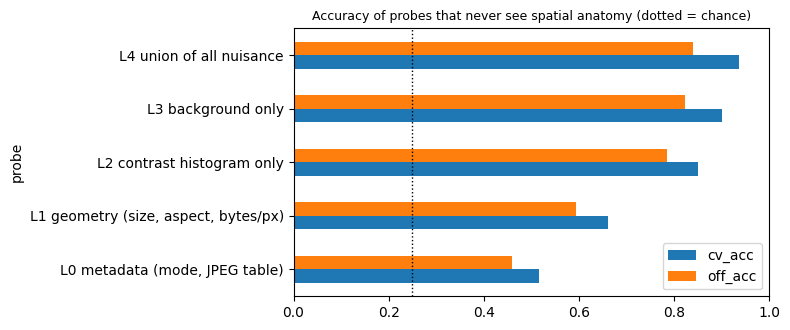

In [5]:
hgb = lambda: HistGradientBoostingClassifier(max_iter=150, random_state=0)
def pfull(clf, X): p = np.full((len(X), K), 1e-4); p[:, clf.classes_] = clf.predict_proba(X); return p
def probe_cv(X):
    P = np.zeros((N, K))
    for sp, _, _, te in SP0[:NFOLD]: P[te] = pfull(hgb().fit(X[np.setdiff1d(np.arange(N), te)], y[np.setdiff1d(np.arange(N), te)]), X[te])
    return P
probe_off = lambda X: pfull(hgb().fit(X[tr_off], y[tr_off]), X[te_off])
LADDER = {"L0 metadata (mode, JPEG table)": F0, "L1 geometry (size, aspect, bytes/px)": F1, "L2 contrast histogram only": F2, "L3 background only": F3, "L4 union of all nuisance": FU}
PCV, POFF, rows = {}, {}, []; chance = lambda a: (a - 1/K)/(1 - 1/K)
for nm, X in LADDER.items():
    PCV[nm], POFF[nm] = probe_cv(X), probe_off(X); pc_, po_ = PCV[nm].argmax(1), POFF[nm].argmax(1)
    mcm = MC[te_off]; rows.append(dict(probe=nm, cv_acc=(pc_ == y).mean(), cv_SRI=chance((pc_ == y).mean()), off_acc=(po_ == y[te_off]).mean(), off_SRI=chance((po_ == y[te_off]).mean()),
                                       off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
ladder = pd.DataFrame(rows).set_index("probe").round(3); print(ladder.to_string()); ladder.to_csv(f"{OUT}/table_shortcut_ladder.csv")
fig, ax = plt.subplots(figsize=(8, 3.4)); ladder[["cv_acc", "off_acc"]].plot.barh(ax=ax); ax.axvline(1/K, color="k", ls=":", lw=1); ax.set_xlim(0, 1); ax.set_title("Accuracy of probes that never see spatial anatomy (dotted = chance)", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_ladder.png", dpi=150); plt.show()

## 4. Counter-Shortcut Set (CSS)
CSS = images where the cross-fitted union probe gives the **true class probability < 0.10**. A model that only follows nuisance cues fails here; accuracy on CSS (**CSA**) measures anatomy-based reliability. `SSF` = share of images the union probe already gets right.

SSF (CV): 0.936 of images are solved by nuisance channels alone | CSS size: CV=300 (0.043), official=210
CSS composition by class: {'glioma': 127, 'meningioma': 106, 'pituitary': 43, 'notumor': 24}
CSS composition by format: {'RGB|q38|other': 172, 'L|q116|std': 70, 'RGB|q38|std': 58}


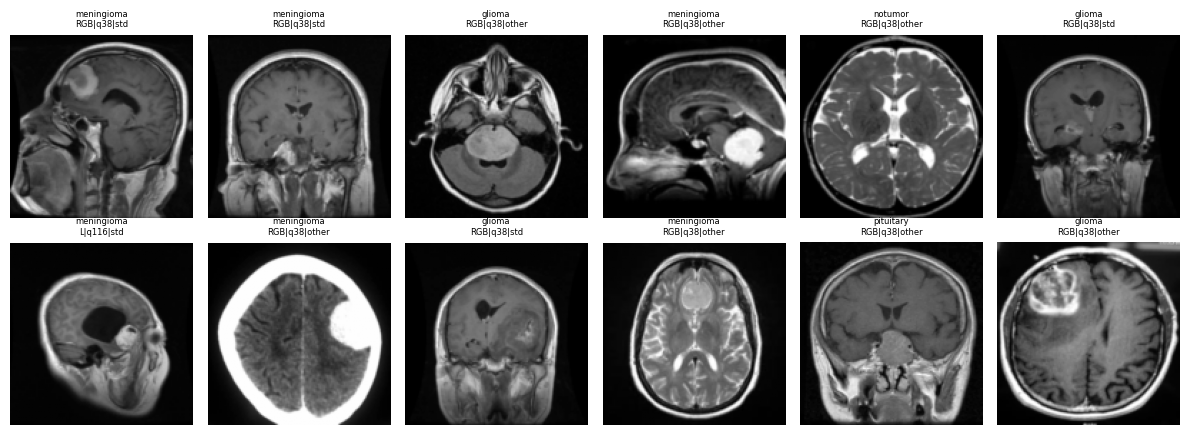

In [6]:
pu = PCV["L4 union of all nuisance"]; CSS = pu[np.arange(N), y] < .10
po = POFF["L4 union of all nuisance"]; CSSOFF = np.zeros(N, bool); CSSOFF[te_off] = po[np.arange(len(te_off)), y[te_off]] < .10
print(f"SSF (CV): {(pu.argmax(1) == y).mean():.3f} of images are solved by nuisance channels alone | CSS size: CV={int(CSS.sum())} ({CSS.mean():.3f}), official={int(CSSOFF.sum())}")
print("CSS composition by class:", pd.Series(np.array(classes)[y[CSS]]).value_counts().to_dict()); print("CSS composition by format:", pd.Series(df.fg.values[CSS]).value_counts().head(5).to_dict())
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4)); ix = np.random.RandomState(0).choice(np.where(CSS)[0], 12, replace=False)
for a, i in zip(ax.ravel(), ix): a.imshow(Xr[i], cmap="gray"); a.axis("off"); a.set_title(f"{classes[y[i]]}\n{df.fg[i]}", fontsize=6)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_css_examples.png", dpi=140); plt.show()

## 5. Models and methods
- `erm`: baseline. `cfr`: Contrast and Framing Randomisation (class-independent intervention on the nuisance channels the ladder found).
- `poe_050`, `poe_100`: product-of-experts with strength 0.5 and 1.0; the **union nuisance probe** (cross-fitted) is the bias expert.
- `ipw`: inverse propensity weighting, weight = p(y) / p_nuisance(y | nuisance), clipped to [0.2, 5]. `ipw_cfr`: IPW + CFR on half of each batch (**proposed**).
Same optimiser, epochs and base augmentation for all. Epoch selection: 0.5 x per-cell accuracy + 0.5 x accuracy on CSS images of the validation fold.

In [7]:
T0 = torch.empty(Xr.shape, dtype=torch.float16, device=dev)
for i in range(0, N, 500): T0[i:i+500] = torch.as_tensor((Xr[i:i+500].astype(np.float32)/255 - .45)/.225).half().to(dev)
yt_all, ct_all = torch.as_tensor(y).to(dev), torch.as_tensor(cid).to(dev)
def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb): super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1, 3, -1, -1))
    def forward(s, x): return s.c(s.fmap(x).mean((2, 3)))
def aug_base(x):
    if np.random.rand() < .5: x = x.flip(-1)
    return x*(1 + .3*(torch.rand(len(x), 1, 1, device=x.device) - .5))
def cfr_aug(x):          # class-independent randomisation of contrast (monotone and non-monotone curves, inversion) and framing (zoom, aspect, rotation, shift)
    B, dv = x.shape[0], x.device; u = (x.float()*.225 + .45).clamp(0, 1)
    kn = torch.rand(B, 6, device=dv); kn = torch.where(torch.rand(B, 1, device=dv) > .15, torch.sort(kn, 1).values, kn)
    pos = u*5; i0 = pos.floor().clamp(0, 4).long(); fr = pos - i0.float()
    k0 = torch.gather(kn, 1, i0.view(B, -1)).view_as(u); k1 = torch.gather(kn, 1, (i0 + 1).view(B, -1)).view_as(u)
    out = k0 + (k1 - k0)*fr; pass          # no inversion in v7
    ang = (torch.rand(B, device=dv) - .5)*.42; zm = .85 + .35*torch.rand(B, device=dv); asp = .85 + .3*torch.rand(B, device=dv); th = torch.zeros(B, 2, 3, device=dv)
    th[:, 0, 0] = zm*asp*torch.cos(ang); th[:, 0, 1] = -zm*torch.sin(ang); th[:, 1, 0] = zm*asp*torch.sin(ang); th[:, 1, 1] = zm*torch.cos(ang); th[:, :, 2] = (torch.rand(B, 2, device=dv) - .5)*.2
    out = F.grid_sample(out.unsqueeze(1), F.affine_grid(th, (B, 1, IMG, IMG), align_corners=False), padding_mode="border", align_corners=False).squeeze(1)
    out = (out + .03*torch.randn_like(out)).clamp(0, 1)
    if np.random.rand() < .5: out = out.flip(-1)
    return (out - .45)/.225
@torch.no_grad()
def predx(m, x):
    m.eval(); out = []
    for i in range(0, len(x), 256):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): out.append(F.softmax(m(x[i:i+256]).float(), 1).cpu())
    return torch.cat(out).numpy()
probs = lambda m, X, idx: predx(m, X[torch.as_tensor(idx).to(dev)])
def vscore(m, va):
    p = probs(m, T0, va).argmax(1); c = p == y[va]; a = np.bincount(cid[va], weights=c, minlength=NC); n = np.bincount(cid[va], minlength=NC); ok = n >= 3
    s = CSS[va]; return .5*(a[ok]/n[ok]).mean() + .5*(c[s].mean() if s.any() else (a[ok]/n[ok]).mean())
def bias_logp(tr, seed):                      # cross-fitted union-nuisance expert
    lb = np.zeros((N, K), np.float32)
    for a, b in StratifiedGroupKFold(4, shuffle=True, random_state=seed).split(tr, y[tr], df.grp.values[tr]): lb[tr[b]] = np.log(np.clip(pfull(hgb().fit(FU[tr[a]], y[tr[a]]), FU[tr[b]]), 1e-3, 1))
    return torch.as_tensor(lb).to(dev)
def fit(bb, method, tr, va, seed, LB=None):
    torch.manual_seed(seed); np.random.seed(seed); m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4); sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS*int(np.ceil(len(tr)/BATCH)))
    scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda")); best = -1
    lprior = torch.log(torch.as_tensor(np.bincount(y[tr], minlength=K)/len(tr) + 1e-9, dtype=torch.float32)).to(dev); alpha = {"poe_050": .5, "poe_100": 1.0}.get(method, 0.0)
    for ep in range(EPOCHS):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev)
            if len(ix) < 4: sched.step(); continue
            x = aug_base(T0[ix])
            if method in ("cfr", "ipw_cfr"):                      # CFR touches only half of each batch, so clean images stay in distribution
                x = torch.where(torch.rand(len(ix), 1, 1, device=dev) < .5, cfr_aug(T0[ix]).to(x.dtype), x)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): lo = m(x)
            lo = lo.float(); yy = yt_all[ix]
            if alpha: lo = lo + alpha*LB[ix]                        # PoE: the bias expert absorbs the shortcut during training
            l = F.cross_entropy(lo, yy, reduction="none")
            if method in ("ipw", "ipw_cfr"):                        # stabilised inverse propensity weights p(y) / p_nuisance(y | nuisance)
                w = torch.exp(lprior[yy] - LB[ix, yy]).clamp(.2, 5); l = l*(w/w.mean())
            loss = l.mean(); opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = vscore(m, va)
        if a >= best: best, st = a, {k_: v_.clone() for k_, v_ in m.state_dict().items()}
    m.load_state_dict(st); return m, best

## 6. Experiments (resumable)

In [8]:
METHODS = ["erm", "cfr", "poe_050", "poe_100", "ipw", "ipw_cfr"]; BASE, PROP = "erm", "ipw_cfr"; NEEDS_LB = ("poe_050", "poe_100", "ipw", "ipw_cfr")
def run_grid(bb, seeds):
    pbar = tqdm(total=len(seeds)*(NFOLD + 1)*len(METHODS), desc=bb)
    for seed in seeds:
        for sp, tr, va, te in make_splits(seed):
            LB = bias_logp(tr, seed)
            for mt in METHODS:
                f = f"{RUNS}/{bb}__{mt}__s{seed}__{sp}.npz"
                if os.path.exists(f): pbar.update(1); continue
                m, vs = fit(bb, mt, tr, va, seed, LB); p = probs(m, T0, te)
                if sp in ("f0", "off") and seed == seeds[0]: torch.save(m.state_dict(), f"{MODELS}/{bb}__{mt}__{sp}.pt")
                np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), vscore=vs)
                del m; torch.cuda.empty_cache() if dev == "cuda" else None; pbar.update(1)
run_grid(ARCH1, SEEDS1)
if ARCH2: run_grid(ARCH2, SEEDS2)

convnext_tiny:   0%|          | 0/108 [00:00<?, ?it/s]

resnet50:   0%|          | 0/36 [00:00<?, ?it/s]

## 7. Results: clean accuracy, CSA, missing-cell accuracy, worst cell (CV and official split)

In [9]:
ARCHS_RUN = [a for a in (ARCH1, ARCH2) if a]
def load_runs():
    raw = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        if os.path.basename(f).startswith("fs__"): continue                      # few-shot files are handled in section 10
        bb, mt, s, sp = os.path.basename(f)[:-4].split("__"); z = np.load(f); raw.setdefault((bb, mt, int(s[1:])), {})[sp] = {a: z[a] for a in z.files}
    R, OFF = {}, {}
    for key, d in raw.items():
        if all(f"f{k}" in d for k in range(NFOLD)):
            e = dict(runs=[d[f"f{k}"] for k in range(NFOLD)], pred=np.zeros(N, np.int64), conf=np.zeros(N, np.float32))
            for r in e["runs"]: e["pred"][r["te"]] = r["pred"]; e["conf"][r["te"]] = r["conf"]
            R[key] = e
        if "off" in d: OFF[key] = d["off"]
    return R, OFF
R, OFF = load_runs(); print(len(R), "complete CV combinations |", len(OFF), "official-split runs")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_on(idx, pred, conf, css, min_cell):
    yy = y[idx]; c = pred == yy; r = dict(acc=c.mean(), macro_f1=f1_score(yy, pred, average="macro"), ece=ece(conf, c))
    s = css[idx]; r["csa"] = c[s].mean() if s.any() else np.nan
    mm = MC[idx]; r["missing_cell_acc"] = c[mm].mean() if mm.any() else np.nan; r["missing_cell_pred_notumor"] = (pred[mm] == NOTU).mean() if mm.any() else np.nan
    a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= min_cell; r["worst_cell"], r["avg_cell"] = (a[ok]/n[ok]).min(), (a[ok]/n[ok]).mean()
    f_ = fc_strict[idx]; r["acc_fc_strict"] = c[f_].mean() if f_.any() else np.nan; return r
cols = ["acc", "macro_f1", "ece", "csa", "missing_cell_acc", "worst_cell", "acc_fc_strict"]
per = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(np.arange(N), e["pred"], e["conf"], CSS, MIN_CELL)) for (bb, mt, s), e in R.items()]); per.to_csv(f"{OUT}/per_seed_cv.csv", index=False)
idx_ = pd.MultiIndex.from_product([ARCHS_RUN, METHODS], names=["arch", "method"]); g = per.groupby(["arch", "method"])
tab = (g[cols].mean().round(4).astype(str) + " +/- " + g[cols].std().fillna(0).round(4).astype(str)).reindex(idx_).dropna(how="all")
print("CROSS-VALIDATION (pooled out-of-fold, duplicate-safe). csa = accuracy on counter-shortcut images"); print(tab.to_string()); tab.to_csv(f"{OUT}/table_cv.csv")
off = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(r["te"], r["pred"], r["conf"], CSSOFF, 10)) for (bb, mt, s), r in OFF.items()])
if len(off):
    go = off.groupby(["arch", "method"]); otab = (go[cols].mean().round(4).astype(str) + " +/- " + go[cols].std().fillna(0).round(4).astype(str)).reindex(idx_).dropna(how="all")
    print("\nOFFICIAL SPLIT (train Training, test Testing). missing_cell_acc = the never-seen glioma/format cell"); print(otab.to_string()); otab.to_csv(f"{OUT}/table_official.csv")

24 complete CV combinations | 24 official-split runs
CROSS-VALIDATION (pooled out-of-fold, duplicate-safe). csa = accuracy on counter-shortcut images
                                     acc           macro_f1                ece                csa   missing_cell_acc         worst_cell      acc_fc_strict
arch          method                                                                                                                                      
convnext_tiny erm      0.9713 +/- 0.0051  0.9708 +/- 0.0052  0.0146 +/- 0.0022  0.7678 +/- 0.0366  0.5702 +/- 0.0856  0.5702 +/- 0.0856  0.8737 +/- 0.0269
              cfr      0.9696 +/- 0.0033  0.9691 +/- 0.0033  0.0103 +/- 0.0024  0.7633 +/- 0.0306     0.5 +/- 0.0658     0.5 +/- 0.0658   0.881 +/- 0.0223
              poe_050  0.9615 +/- 0.0033  0.9612 +/- 0.0033  0.0069 +/- 0.0031    0.83 +/- 0.0186  0.6842 +/- 0.0228  0.6842 +/- 0.0228  0.8575 +/- 0.0035
              poe_100  0.8729 +/- 0.0095  0.8724 +/- 0.0097   0.031 +/- 0.0

## 8. Statistics: duplicate-aware bootstrap, paired differences vs ERM

In [10]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug); B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot_ratio(v, mask):
    num = np.bincount(gi, weights=v*mask, minlength=NG); den = np.bincount(gi, weights=mask, minlength=NG); return num[IX].sum(1)/np.maximum(den[IX].sum(1), 1e-9)
den_m = np.zeros((NG, NC)); np.add.at(den_m, (gi, cid), 1.0)
def boot_worst(v):
    num = np.zeros((NG, NC)); np.add.at(num, (gi, cid), v); out = np.zeros(B)
    for b in range(B): n_, d_ = num[IX[b]].sum(0), den_m[IX[b]].sum(0); ok = okcell & (d_ > 0); out[b] = (n_[ok]/d_[ok]).min()
    return out
ONE, OFFM = np.ones(N), np.zeros(N); OFFM[te_off] = 1
cvspec = {"acc": ONE, "csa": CSS.astype(float), "missing_cell_acc": MC.astype(float), "acc_fc_strict": fc_strict.astype(float)}
offspec = {"off_acc": OFFM, "off_csa": CSSOFF.astype(float), "off_missing_cell_acc": OFFM*MC}
seeds_of = {ARCH1: SEEDS1, ARCH2: SEEDS2}; bres = {}
for bb in ARCHS_RUN:
    for mt in METHODS:
        ss = [s for s in seeds_of[bb] if (bb, mt, s) in R]; so = [s for s in seeds_of[bb] if (bb, mt, s) in OFF]
        if not ss: continue
        cv_c = np.mean([(R[(bb, mt, s)]["pred"] == y) for s in ss], 0).astype(float); d = {k: boot_ratio(cv_c, mk) for k, mk in cvspec.items()}; d["worst_cell"] = boot_worst(cv_c)
        if so:
            of_c = np.zeros(N)
            for s in so: of_c[OFF[(bb, mt, s)]["te"]] += (OFF[(bb, mt, s)]["pred"] == y[OFF[(bb, mt, s)]["te"]])/len(so)
            d.update({k: boot_ratio(of_c, mk) for k, mk in offspec.items()})
        bres[(bb, mt)] = d
ci = lambda a: f"{a.mean():.3f} [{np.percentile(a,2.5):.3f},{np.percentile(a,97.5):.3f}]"
ci_df = pd.DataFrame([dict(arch=bb, method=mt, **{k: ci(v) for k, v in d.items()}) for (bb, mt), d in bres.items()]); print(ci_df.to_string()); ci_df.to_csv(f"{OUT}/table_ci.csv", index=False)
rows = []
for bb in ARCHS_RUN:
    for mt in METHODS:
        if mt == BASE or (bb, mt) not in bres or (bb, BASE) not in bres: continue
        r = dict(arch=bb, method=mt)
        for k in bres[(bb, mt)]:
            dd = bres[(bb, mt)][k] - bres[(bb, BASE)][k]; r[f"d_{k}"] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}]"; r[f"P>0_{k}"] = round(float((dd > 0).mean()), 3)
        rows.append(r)
diff_df = pd.DataFrame(rows); print("\nDifferences vs ERM (positive = better):"); print(diff_df.T.to_string()); diff_df.to_csv(f"{OUT}/table_diff_vs_erm.csv", index=False)

             arch   method                  acc                  csa     missing_cell_acc        acc_fc_strict           worst_cell              off_acc              off_csa off_missing_cell_acc
0   convnext_tiny      erm  0.971 [0.967,0.975]  0.768 [0.711,0.818]  0.569 [0.464,0.672]  0.873 [0.846,0.899]  0.568 [0.462,0.671]  0.924 [0.910,0.938]  0.544 [0.474,0.607]  0.085 [0.034,0.143]
1   convnext_tiny      cfr  0.970 [0.966,0.974]  0.764 [0.709,0.817]  0.500 [0.400,0.610]  0.881 [0.857,0.905]  0.500 [0.400,0.610]  0.941 [0.927,0.953]  0.633 [0.569,0.698]  0.248 [0.145,0.354]
2   convnext_tiny  poe_050  0.962 [0.957,0.966]  0.831 [0.781,0.875]  0.683 [0.591,0.775]  0.857 [0.828,0.885]  0.679 [0.586,0.766]  0.938 [0.925,0.950]  0.672 [0.601,0.734]  0.249 [0.145,0.350]
3   convnext_tiny  poe_100  0.873 [0.864,0.881]  0.803 [0.759,0.847]  0.726 [0.631,0.819]  0.776 [0.743,0.807]  0.657 [0.512,0.768]  0.820 [0.801,0.839]  0.725 [0.663,0.781]  0.371 [0.250,0.492]
4   convnext_tiny      ip

## 9. Are deep-model errors explained by the shortcut probe? (official split, unseen cell)

In [11]:
pu_off = POFF["L4 union of all nuisance"].argmax(1); yo = y[te_off]; mcm = MC[te_off]; rows = []; conf_tab = {}
for (bb, mt, s), r in OFF.items():
    if s != (SEEDS1 if bb == ARCH1 else SEEDS2)[0] or r["te"].shape != te_off.shape: continue
    wrong = r["pred"] != yo; rows.append(dict(arch=bb, method=mt, agree_with_probe=(r["pred"] == pu_off).mean(), share_of_errors_probe_also_makes_same_error=(pu_off[wrong] == r["pred"][wrong]).mean(),
                                              missing_cell_agree_with_probe=(r["pred"][mcm] == pu_off[mcm]).mean() if mcm.any() else np.nan))
    if mcm.any(): conf_tab[f"{bb}|{mt}"] = np.bincount(r["pred"][mcm], minlength=K)
if mcm.any(): conf_tab["nuisance probe (union)"] = np.bincount(pu_off[mcm], minlength=K)
ex = pd.DataFrame(rows).set_index(["arch", "method"]).round(3); print(ex.to_string()); ex.to_csv(f"{OUT}/table_explained_by_shortcut.csv")
if mcm.any():
    ct_ = pd.DataFrame(conf_tab, index=classes).T; ct_.insert(0, "n", int(mcm.sum())); print("\nPredictions on the never-seen cell (true class =", classes[int(np.bincount(y[te_off][mcm]).argmax())], "):"); print(ct_.to_string()); ct_.to_csv(f"{OUT}/table_missing_cell_predictions.csv")

                       agree_with_probe  share_of_errors_probe_also_makes_same_error  missing_cell_agree_with_probe
arch          method                                                                                               
convnext_tiny cfr                 0.856                                        0.385                          0.316
              erm                 0.866                                        0.493                          0.513
              ipw                 0.833                                        0.172                          0.145
              ipw_cfr             0.823                                        0.142                          0.132
              poe_050             0.836                                        0.232                          0.158
              poe_100             0.746                                        0.053                          0.105
resnet50      cfr                 0.870                                 

## 9b. The shortcut dial (no retraining) and the accuracy-reliability trade-off
A PoE model learned `f(x)` while a bias expert supplied the shortcut. At test time we can add the shortcut back with strength `beta`: `log p_f + beta * log p_bias`. `beta = 0` is fully debiased, `beta = alpha` behaves like ERM. One trained model gives a whole trade-off curve.

                                       acc    csa  missing_cell_acc
arch          method  protocol beta                                
convnext_tiny poe_050 CV       0.00  0.962  0.830             0.684
                               0.25  0.974  0.794             0.658
                               0.50  0.977  0.742             0.583
                               0.75  0.977  0.682             0.539
                               1.00  0.976  0.613             0.491
                      official 0.00  0.938  0.671             0.250
                               0.25  0.943  0.637             0.215
                               0.50  0.938  0.576             0.145
                               0.75  0.925  0.486             0.066
                               1.00  0.908  0.362             0.009
              poe_100 CV       0.00  0.873  0.803             0.728
                               0.25  0.933  0.774             0.715
                               0.50  0.961  0.73

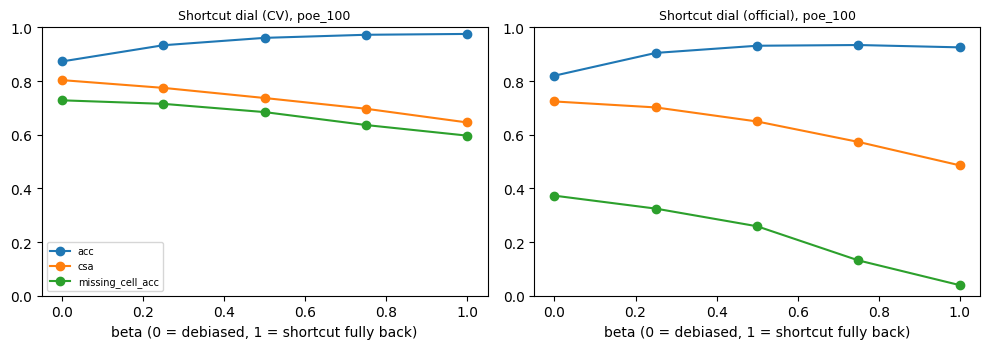

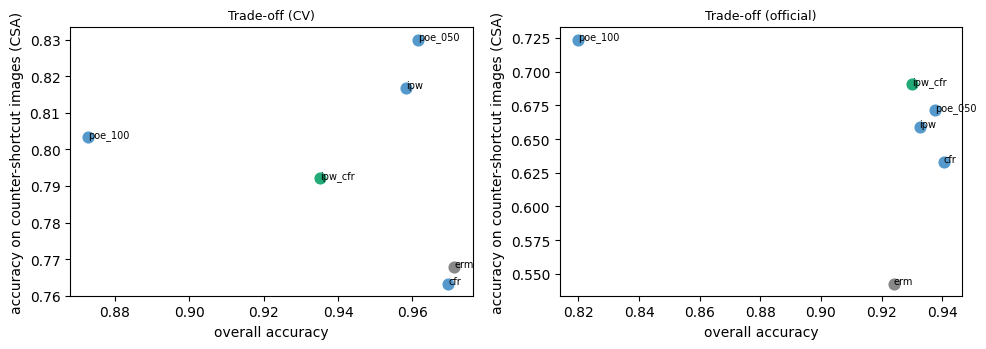

In [12]:
BETAS = [0, .25, .5, .75, 1.0]; L4 = "L4 union of all nuisance"; rows = []
lb_cv, lb_off = np.log(np.clip(PCV[L4], 1e-3, 1)), np.log(np.clip(POFF[L4], 1e-3, 1))
for (bb, mt, s), e in R.items():
    if not mt.startswith("poe"): continue
    pm = np.zeros((N, K), np.float32)
    for r in e["runs"]: pm[r["te"]] = r["prob"].astype(np.float32)
    lp = np.log(np.clip(pm, 1e-6, 1))
    for beta in BETAS:
        c = (lp + beta*lb_cv).argmax(1) == y; rows.append(dict(arch=bb, method=mt, seed=s, protocol="CV", beta=beta, acc=c.mean(), csa=c[CSS].mean(), missing_cell_acc=c[MC].mean()))
for (bb, mt, s), r in OFF.items():
    if not mt.startswith("poe") or r["te"].shape != te_off.shape: continue
    lp = np.log(np.clip(r["prob"].astype(np.float32), 1e-6, 1)); yo = y[te_off]
    for beta in BETAS:
        c = (lp + beta*lb_off).argmax(1) == yo; rows.append(dict(arch=bb, method=mt, seed=s, protocol="official", beta=beta, acc=c.mean(), csa=c[CSSOFF[te_off]].mean(), missing_cell_acc=c[MC[te_off]].mean()))
dial = pd.DataFrame(rows)
if len(dial):
    dg = dial.groupby(["arch", "method", "protocol", "beta"])[["acc", "csa", "missing_cell_acc"]].mean().round(3); print(dg.to_string()); dg.to_csv(f"{OUT}/table_shortcut_dial.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for a, pr in zip(ax, ["CV", "official"]):
        d = dial[(dial.arch == ARCH1) & (dial.method == "poe_100") & (dial.protocol == pr)].groupby("beta")[["acc", "csa", "missing_cell_acc"]].mean()
        for col in d: a.plot(d.index, d[col], marker="o", label=col)
        a.set_title(f"Shortcut dial ({pr}), poe_100", fontsize=9); a.set_xlabel("beta (0 = debiased, 1 = shortcut fully back)"); a.set_ylim(0, 1)
    ax[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_dial.png", dpi=150); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a, (nm, d) in zip(ax, [("CV", per), ("official", off)]):
    if len(d) == 0: continue
    gm = d[d.arch == ARCH1].groupby("method")[["acc", "csa"]].mean()
    for mt, r in gm.iterrows(): a.scatter(r.acc, r.csa, s=60, color="#2a7" if mt == PROP else "#888" if mt == BASE else "#59c"); a.annotate(mt, (r.acc, r.csa), fontsize=7)
    a.set_xlabel("overall accuracy"); a.set_ylabel("accuracy on counter-shortcut images (CSA)"); a.set_title(f"Trade-off ({nm})", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_tradeoff.png", dpi=150); plt.show()

## 10. Few-shot recovery curve for the missing cell
Add k images of the unseen cell to training (repeated x4). Evaluate on **held-out** images of the same cell and on the rest of the official test set (to check nothing else breaks).

cell: glio|RGB|q38|other | shot pool 38 | held-out eval 38 | rest of test 1421
           acc_cell        acc_rest        pred_notumor       
               mean    std     mean    std         mean    std
method  k                                                     
erm     0     0.053  0.026    0.969  0.022        0.579  0.070
        4     0.377  0.132    0.981  0.004        0.298  0.066
        8     0.342  0.254    0.954  0.022        0.377  0.106
        16    0.456  0.055    0.967  0.013        0.246  0.055
        32    0.746  0.080    0.952  0.015        0.158  0.026
ipw_cfr 0     0.228  0.040    0.969  0.002        0.175  0.015
        4     0.342  0.046    0.963  0.003        0.123  0.015
        8     0.518  0.061    0.946  0.009        0.114  0.015
        16    0.605  0.026    0.939  0.010        0.105  0.026
        32    0.746  0.040    0.921  0.018        0.096  0.015


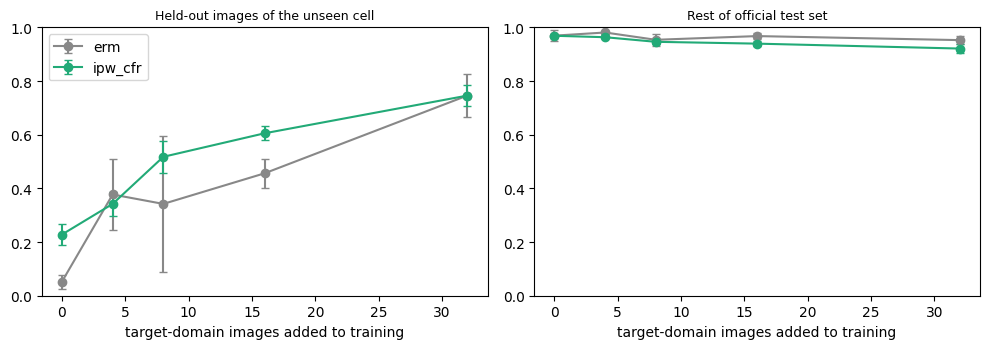

In [13]:
if len(miss):
    mcell = miss[int(np.argmax([ten[c] for c in miss]))]; idx_mc = np.where(cid == mcell)[0]; idx_mc = idx_mc[np.random.RandomState(123).permutation(len(idx_mc))]
    pool, evald = idx_mc[:len(idx_mc)//2], idx_mc[len(idx_mc)//2:]; rest = np.setdiff1d(te_off, idx_mc); print("cell:", cell_names[mcell], "| shot pool", len(pool), "| held-out eval", len(evald), "| rest of test", len(rest))
    for seed in FS_SEEDS:
        sp, tr, va, te = make_splits(seed)[5]; LB = None
        for mt in (BASE, PROP):
            for k in KS:
                f = f"{RUNS}/fs__{ARCH1}__{mt}__s{seed}__k{k}.npz"
                if os.path.exists(f): continue
                trk = np.r_[tr, np.repeat(pool[:k], 4)].astype(int) if k else tr
                LB = bias_logp(np.unique(trk), seed) if mt in NEEDS_LB else None
                m, _ = fit(ARCH1, mt, trk, va, seed, LB); pe, pr = probs(m, T0, evald).argmax(1), probs(m, T0, rest).argmax(1)
                np.savez(f, acc_cell=(pe == y[evald]).mean(), acc_rest=(pr == y[rest]).mean(), pnot=(pe == NOTU).mean()); del m; torch.cuda.empty_cache() if dev == "cuda" else None
    rows = []
    for f in glob.glob(f"{RUNS}/fs__*.npz"):
        _, bb, mt, s, k = os.path.basename(f)[:-4].split("__"); z = np.load(f); rows.append(dict(method=mt, seed=int(s[1:]), k=int(k[1:]), acc_cell=float(z["acc_cell"]), acc_rest=float(z["acc_rest"]), pred_notumor=float(z["pnot"])))
    fs = pd.DataFrame(rows); fsg = fs.groupby(["method", "k"])[["acc_cell", "acc_rest", "pred_notumor"]].agg(["mean", "std"]).round(3); print(fsg.to_string()); fsg.to_csv(f"{OUT}/table_fewshot.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for mt, c in ((BASE, "#888"), (PROP, "#2a7")):
        d = fs[fs.method == mt].groupby("k")
        for a, col, t in zip(ax, ["acc_cell", "acc_rest"], ["Held-out images of the unseen cell", "Rest of official test set"]):
            mu, sd = d[col].mean(), d[col].std().fillna(0); a.errorbar(mu.index, mu, yerr=sd, marker="o", color=c, label=mt, capsize=3); a.set_title(t, fontsize=9); a.set_xlabel("target-domain images added to training"); a.set_ylim(0, 1)
    ax[0].legend(); plt.tight_layout(); plt.savefig(f"{OUT}/fig_fewshot_recovery.png", dpi=150); plt.show()
else: print("No missing cell found in this data subset.")

In [14]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("ladder", ladder), ("diff", diff_df)]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print("Headline numbers:", f"nuisance-union probe CV acc={ladder.iloc[-1].cv_acc}, official={ladder.iloc[-1].off_acc}; contrast-only official={ladder.loc['L2 contrast histogram only'].off_acc}; CSS={int(CSS.sum())} images")
print(sorted(os.listdir(OUT)))

Headline numbers: nuisance-union probe CV acc=0.936, official=0.84; contrast-only official=0.786; CSS=300 images
['cache_v6_N6997.npz', 'config.json', 'fig_css_examples.png', 'fig_fewshot_recovery.png', 'fig_shortcut_dial.png', 'fig_shortcut_ladder.png', 'fig_tradeoff.png', 'models', 'per_seed_cv.csv', 'runs', 'table_ci.csv', 'table_cv.csv', 'table_diff_vs_erm.csv', 'table_explained_by_shortcut.csv', 'table_fewshot.csv', 'table_missing_cell_predictions.csv', 'table_official.csv', 'table_shortcut_dial.csv', 'table_shortcut_ladder.csv', 'tables.tex']


## 11. How to read this and what to write
- **Ladder:** if contrast-only or the union probe approaches the deep model, then "97% accuracy" is largely solvable without spatial anatomy. This is the paper's first headline.
- **CSA:** report deep accuracy on CSS next to overall accuracy. A big gap = reliability is lower than headline numbers.
- **Missing cell:** if every method collapses on the unseen cell and the probe predicts the same wrong class, say clearly that no training-time trick recovers an absent domain, and show the few-shot curve (how many images fix it).
- **If `ipw`, `ipw_cfr`, `poe_050` or `poe_100` help:** report effect sizes with the bootstrap intervals and the clean-accuracy cost. If they do not, report that too; the audit and the recovery curve remain the contribution.
- **Before submission:** literature search (shortcut learning, dataset bias in medical imaging, domain generalisation with contrast randomisation, missing-cell or compositional shift), external dataset test, clinician review of the unseen-cell images, release code plus the format-group labels.